In [ ]:
# =====================================
# IMPORT LIBRARY YANG AKAN DIGUNAKAN
# =====================================
import os, shutil
import zipfile
import random
from random import sample
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import files
from tqdm.notebook import tqdm as tq
import matplotlib.pyplot as plt
from skimage.util.dtype import img_as_ubyte
import cv2
import hashlib
from PIL import Image
import skimage
from collections import Counter
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage.exposure import adjust_gamma
from skimage.util import random_noise
from skimage.filters import gaussian
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Data Wrangling


## Gathering Data

In [ ]:
# ===============================================
# MENGAMBIL MODULE UNTUK KEBUTUHAN UPLOAD FILE
# ===============================================
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rifaagni", "key":"KGAT_a98ff61a259acc19acc73248bb5ae5a3"}'}

In [ ]:
# ==============
# SET KAGGLE
# ==============
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# ====================
# MENGUNDUH DATASET
# ====================
!kaggle datasets download -d soni535/rice-leaf-bacterial-and-fungal-disease
!unzip rice-leaf-bacterial-and-fungal-disease.zip

Streaming output truncated to the last 5000 lines.
  inflating: Rice Leaf Bacterial and Fungal Disease Dataset/Augmented/Augmented Images/Augmented Images/Leaf Blast/augmented_image_129.jpg  
  inflating: Rice Leaf Bacterial and Fungal Disease Dataset/Augmented/Augmented Images/Augmented Images/Leaf Blast/augmented_image_13.jpg  
  inflating: Rice Leaf Bacterial and Fungal Disease Dataset/Augmented/Augmented Images/Augmented Images/Leaf Blast/augmented_image_130.jpg  
  inflating: Rice Leaf Bacterial and Fungal Disease Dataset/Augmented/Augmented Images/Augmented Images/Leaf Blast/augmented_image_131.jpg  
  inflating: Rice Leaf Bacterial and Fungal Disease Dataset/Augmented/Augmented Images/Augmented Images/Leaf Blast/augmented_image_132.jpg  
  inflating: Rice Leaf Bacterial and Fungal Disease Dataset/Augmented/Augmented Images/Augmented Images/Leaf Blast/augmented_image_133.jpg  
  inflating: Rice Leaf Bacterial and Fungal Disease Dataset/Augmented/Augmented Images/Augmented Images/

In [ ]:
# ====================
# MENGUNDUH DATASET
# ====================
!kaggle datasets download -d raihan150146/rice-leaf-diseases-dataset
!unzip rice-leaf-diseases-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/raihan150146/rice-leaf-diseases-dataset
License(s): CC0-1.0
100% 1.78G/1.78G [00:22<00:00, 84.9MB/s]

Archive:  rice-leaf-diseases-dataset.zip
  inflating: Rice leaf disease/Testing data/Bacterial Leaf Blight/IMG_20231014_172819.jpg  
  inflating: Rice leaf disease/Testing data/Bacterial Leaf Blight/IMG_20231014_172829.jpg  
  inflating: Rice leaf disease/Testing data/Bacterial Leaf Blight/IMG_20231014_172829_1.jpg  
  inflating: Rice leaf disease/Testing data/Bacterial Leaf Blight/IMG_20231014_172852.jpg  
  inflating: Rice leaf disease/Testing data/Bacterial Leaf Blight/IMG_20231014_172907.jpg  
  inflating: Rice leaf disease/Testing data/Bacterial Leaf Blight/IMG_20231014_172909.jpg  
  inflating: Rice leaf disease/Testing data/Bacterial Leaf Blight/IMG_20231014_173003.jpg  
  inflating: Rice leaf disease/Testing data/Bacterial Leaf Blight/IMG_20231014_173114.jpg  
  inflating: Rice leaf disease/Testing data/Bacterial Leaf Blight/IMG_2023

In [ ]:
# ====================
# MENGUNDUH DATASET
# ====================
!kaggle datasets download -d gettingintoml/zambali-rice-dataset-v3-1
!unzip zambali-rice-dataset-v3-1.zip

Dataset URL: https://www.kaggle.com/datasets/gettingintoml/zambali-rice-dataset-v3-1
License(s): apache-2.0
100% 9.30M/9.30M [00:00<00:00, 28.0MB/s]

Archive:  zambali-rice-dataset-v3-1.zip
  inflating: ZAMBALI_RICE_DATASET_V3/BACTERIAL_BLIGHT/Bacterial_Blight (1).jpg  
  inflating: ZAMBALI_RICE_DATASET_V3/BACTERIAL_BLIGHT/Bacterial_Blight (22).JPEG  
  inflating: ZAMBALI_RICE_DATASET_V3/BACTERIAL_BLIGHT/Bacterial_Blight (32).jpg  
  inflating: ZAMBALI_RICE_DATASET_V3/BACTERIAL_BLIGHT/Bacterial_Blight (33).jpg  
  inflating: ZAMBALI_RICE_DATASET_V3/BACTERIAL_BLIGHT/Bacterial_Blight (35).jpg  
  inflating: ZAMBALI_RICE_DATASET_V3/BACTERIAL_BLIGHT/Bacterial_Blight (37).jpg  
  inflating: ZAMBALI_RICE_DATASET_V3/BACTERIAL_BLIGHT/Bacterial_Blight (38).jpg  
  inflating: ZAMBALI_RICE_DATASET_V3/BACTERIAL_BLIGHT/Bacterial_Blight (41).jpg  
  inflating: ZAMBALI_RICE_DATASET_V3/BACTERIAL_BLIGHT/Bacterial_Blight (42).jpg  
  inflating: ZAMBALI_RICE_DATASET_V3/BACTERIAL_BLIGHT/Bacterial_Blight (

In [ ]:
# ====================
# MENGUNDUH DATASET
# ====================
!kaggle datasets download -d anshulm257/rice-disease-dataset
!unzip rice-disease-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/anshulm257/rice-disease-dataset
License(s): unknown
100% 0.99G/0.99G [00:07<00:00, 146MB/s]

Archive:  rice-disease-dataset.zip
  inflating: Rice_Leaf_AUG/Bacterial Leaf Blight/20231006_164208.jpg  
  inflating: Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172818.jpg  
  inflating: Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172819.jpg  
  inflating: Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172829.jpg  
  inflating: Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172829_1.jpg  
  inflating: Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172830.jpg  
  inflating: Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172838.jpg  
  inflating: Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172840.jpg  
  inflating: Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172841.jpg  
  inflating: Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172843.jpg  
  inflating: Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172845.jpg  
  in

In [ ]:
# ====================
# MENGUNDUH DATASET
# ====================
!kaggle datasets download -d sham69/rice-leaf-disease-detection-dataset
!unzip rice-leaf-disease-detection-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Train-20260428T163352Z-3-001/Train/Brown Spot/Field/aug_0_5916.jpg  
  inflating: Train-20260428T163352Z-3-001/Train/Brown Spot/Field/aug_0_5917.jpg  
  inflating: Train-20260428T163352Z-3-001/Train/Brown Spot/Field/aug_0_5918.jpg  
  inflating: Train-20260428T163352Z-3-001/Train/Brown Spot/Field/aug_0_5926.jpg  
  inflating: Train-20260428T163352Z-3-001/Train/Brown Spot/Field/aug_0_5936.jpg  
  inflating: Train-20260428T163352Z-3-001/Train/Brown Spot/Field/aug_0_5994.jpg  
  inflating: Train-20260428T163352Z-3-001/Train/Brown Spot/Field/aug_0_6014.jpg  
  inflating: Train-20260428T163352Z-3-001/Train/Brown Spot/Field/aug_0_6035.jpg  
  inflating: Train-20260428T163352Z-3-001/Train/Brown Spot/Field/aug_0_6051.jpg  
  inflating: Train-20260428T163352Z-3-001/Train/Brown Spot/Field/aug_0_6061.jpg  
  inflating: Train-20260428T163352Z-3-001/Train/Brown Spot/Field/aug_0_6076.jpg  
  inflating: Train-20260428T163352Z-3-001/Train

In [ ]:
# ====================
# MENGUNDUH DATASET
# ====================
!kaggle datasets download -d dellcat/datasetofleafdiseasesandpestsofagriculturalplants
!unzip datasetofleafdiseasesandpestsofagriculturalplants.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset of leaf diseases and pests of agricultural plants/Train/Tomato Target Spot/Tomato Target Spot 356.JPG  
  inflating: Dataset of leaf diseases and pests of agricultural plants/Train/Tomato Target Spot/Tomato Target Spot 357.JPG  
  inflating: Dataset of leaf diseases and pests of agricultural plants/Train/Tomato Target Spot/Tomato Target Spot 358.JPG  
  inflating: Dataset of leaf diseases and pests of agricultural plants/Train/Tomato Target Spot/Tomato Target Spot 359.JPG  
  inflating: Dataset of leaf diseases and pests of agricultural plants/Train/Tomato Target Spot/Tomato Target Spot 36.JPG  
  inflating: Dataset of leaf diseases and pests of agricultural plants/Train/Tomato Target Spot/Tomato Target Spot 360.JPG  
  inflating: Dataset of leaf diseases and pests of agricultural plants/Train/Tomato Target Spot/Tomato Target Spot 361.JPG  
  inflating: Dataset of leaf diseases and pests of agricultural plants/Trai

In [ ]:
# ====================
# MENGUNDUH DATASET
# ====================
!kaggle datasets download -d emmarex/plantdisease
!unzip plantdisease.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-74

In [ ]:
# ====================
# MENGUNDUH DATASET
# ====================
!kaggle datasets download -d trainingdatapro/car-masks
!unzip car-masks.zip

Dataset URL: https://www.kaggle.com/datasets/trainingdatapro/car-masks
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 139M/139M [00:01<00:00, 96.1MB/s]

Archive:  car-masks.zip
  inflating: cars/img/IMG_9208.jpg   
  inflating: cars/img/IMG_9209.jpg   
  inflating: cars/img/IMG_9210.jpg   
  inflating: cars/img/IMG_9211.jpg   
  inflating: cars/img/IMG_9212.jpg   
  inflating: cars/img/IMG_9213.jpg   
  inflating: cars/img/IMG_9214.jpg   
  inflating: cars/img/IMG_9215.jpg   
  inflating: cars/img/IMG_9218.jpg   
  inflating: cars/img/IMG_9219.jpg   
  inflating: cars/img/IMG_9222.jpg   
  inflating: cars/img/IMG_9223.jpg   
  inflating: cars/img/IMG_9225.jpg   
  inflating: cars/img/IMG_9228.jpg   
  inflating: cars/img/IMG_9229.jpg   
  inflating: cars/img/IMG_9230.jpg   
  inflating: cars/img/IMG_9234.jpg   
  inflating: cars/img/IMG_9236.jpg   
  inflating: cars/img/IMG_9240.jpg   
  inflating: cars/img/IMG_9243.jpg   
  inflating: cars

In [ ]:
# ====================
# MENGUNDUH DATASET
# ====================
!kaggle datasets download -d phylake1337/fire-dataset
!unzip fire-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset
License(s): CC0-1.0
100% 387M/387M [00:09<00:00, 42.0MB/s]

Archive:  fire-dataset.zip
  inflating: fire_dataset/fire_images/fire.1.png  
  inflating: fire_dataset/fire_images/fire.10.png  
  inflating: fire_dataset/fire_images/fire.100.png  
  inflating: fire_dataset/fire_images/fire.101.png  
  inflating: fire_dataset/fire_images/fire.102.png  
  inflating: fire_dataset/fire_images/fire.103.png  
  inflating: fire_dataset/fire_images/fire.104.png  
  inflating: fire_dataset/fire_images/fire.105.png  
  inflating: fire_dataset/fire_images/fire.106.png  
  inflating: fire_dataset/fire_images/fire.107.png  
  inflating: fire_dataset/fire_images/fire.108.png  
  inflating: fire_dataset/fire_images/fire.109.png  
  inflating: fire_dataset/fire_images/fire.11.png  
  inflating: fire_dataset/fire_images/fire.110.png  
  inflating: fire_dataset/fire_images/fire.111.png  
  inflating: fire_dataset/fire_images/fire.112.png  

In [ ]:
# ====================
# MENGUNDUH DATASET
# ====================
!kaggle datasets download -d shamsaddin97/image-captioning-dataset-random-images
!unzip image-captioning-dataset-random-images.zip

Dataset URL: https://www.kaggle.com/datasets/shamsaddin97/image-captioning-dataset-random-images
License(s): unknown
100% 30.4M/30.4M [00:00<00:00, 73.8MB/s]

Archive:  image-captioning-dataset-random-images.zip
  inflating: images/0.jpg            
  inflating: images/1002.jpg         
  inflating: images/1005.jpg         
  inflating: images/1008.jpg         
  inflating: images/1011.jpg         
  inflating: images/1014.jpg         
  inflating: images/1017.jpg         
  inflating: images/102.jpg          
  inflating: images/1020.jpg         
  inflating: images/1023.jpg         
  inflating: images/1026.jpg         
  inflating: images/1029.jpg         
  inflating: images/1032.jpg         
  inflating: images/1035.jpg         
  inflating: images/1038.jpg         
  inflating: images/1041.jpg         
  inflating: images/1044.jpg         
  inflating: images/1047.jpg         
  inflating: images/105.jpg          
  inflating: images/1050.jpg         
  inflating: images/1053.jpg

In [ ]:
# ===========================================================
# MENGGABUNGKAN CITRA DARI BEBERAPA SUMBER SESUAI KELASNYA
# ===========================================================
sources = {
    "Blast": [
        "/content/Rice Leaf Bacterial and Fungal Disease Dataset/Original/Original Images/Original Images/Leaf Blast",
        "/content/Train-20260428T163352Z-3-001/Train/Leaf Blast/Field",
        "/content/Test-20260428T163339Z-3-001/Test/Leaf Blast/Field",
        "/content/Valid-20260428T163357Z-3-001/Valid/Leaf Blast",
        "/content/Rice leaf disease/Testing data/Leaf Blast",
        "/content/Rice leaf disease/Training data/Leaf Blast",
        "/content/Rice leaf disease/Validation data/Leaf Blast",
        "/content/ZAMBALI_RICE_DATASET_V3/LEAF_BLAST",
        "/content/Rice_Leaf_AUG/Leaf Blast",
        "/content/Dataset of leaf diseases and pests of agricultural plants/Test/Rice Blast"
    ],
    "BrownSpot":[
        "/content/Rice Leaf Bacterial and Fungal Disease Dataset/Original/Original Images/Original Images/Brown Spot",
        "/content/Test-20260428T163339Z-3-001/Test/Brown Spot/Field",
        "/content/Train-20260428T163352Z-3-001/Train/Brown Spot/Field",
        "/content/Valid-20260428T163357Z-3-001/Valid/Brown Spot/Field",
        "/content/ZAMBALI_RICE_DATASET_V3/BROWN_SPOT",
        "/content/Rice_Leaf_AUG/Brown Spot",
        "/content/Rice leaf disease/Testing data/Brown Spot",
        "/content/Rice leaf disease/Validation data/Brown Spot",
        "/content/Dataset of leaf diseases and pests of agricultural plants/Train/Rice Brownspot"
    ],
    "Healthy":[
        "/content/Train-20260428T163352Z-3-001/Train/Healthy/Field",
        "/content/Test-20260428T163339Z-3-001/Test/Healthy/Field",
        "/content/Valid-20260428T163357Z-3-001/Valid/Healthy/Field",
        "/content/Train-20260428T163352Z-3-001/Train/Healthy/Lab",
        "/content/Rice leaf disease/Testing data/Healthy Rice Leaf",
        "/content/Rice leaf disease/Training data/Healthy Rice Leaf",
        "/content/Rice leaf disease/Validation data/Healthy Rice Leaf",
        "/content/Rice Leaf Bacterial and Fungal Disease Dataset/Original/Original Images/Original Images/Healthy Rice Leaf",
        "/content/ZAMBALI_RICE_DATASET_V3/HEALTHY",
        "/content/Rice_Leaf_AUG/Healthy Rice Leaf"
    ],
    "Tungro":[
        "/content/Test-20260428T163339Z-3-001/Test/Tungro/Field",
        "/content/Train-20260428T163352Z-3-001/Train/Tungro/Field",
        "/content/Valid-20260428T163357Z-3-001/Valid/Tungro/Field",
        "/content/Valid-20260428T163357Z-3-001/Valid/Tungro/Lab",
        "/content/Train-20260428T163352Z-3-001/Train/Tungro/Lab",
        "/content/Test-20260428T163339Z-3-001/Test/Tungro/Lab",
        "/content/Dataset of leaf diseases and pests of agricultural plants/Train/Rice Tungro"
    ],
    "Unknown":[
        "/content/plantvillage/PlantVillage/Tomato__Tomato_mosaic_virus",
        "/content/cars/img",
        "/content/fire_dataset/non_fire_images",
        "/content/images"
    ]
}

# ==================================================================
# MENYUSUN ULANG GAMBAR KE DALAM SATU DIREKTORI BERDASARKAN KELAS
# ==================================================================
data_images = "rice_leaf_disease_images/"

for class_name, folder_list in sources.items():
  output_dir = os.path.join(data_images, class_name)
  # buat folder output, skip jika sudah ada
  os.makedirs(output_dir, exist_ok=True)

  counter = 1
  for folder in folder_list:
    if not os.path.exists(folder):
      print(f'Folder tidak ditemukan: {folder}')
      continue
    for file in os.listdir(folder):
      if file.lower().endswith(('.jpg', '.jpeg', '.png')):
        src = os.path.join(folder, file)
        # rename file agar tidak konflik nama
        dst = os.path.join(output_dir, f"{class_name}_{counter:04d}.jpg")
        shutil.copy(src, dst)
        counter += 1

  print(f"{class_name}: {counter-1} gambar")

Blast: 2587 gambar
BrownSpot: 3293 gambar
Healthy: 2597 gambar
Tungro: 2352 gambar
Unknown: 2683 gambar


## Assesing dan Cleaning Data

In [ ]:
# ========================
# CEK KUALITAS DATASET
# ========================
records = []

for label in os.listdir(data_images):
    class_path = os.path.join(data_images, label)
    if not os.path.isdir(class_path):
        continue
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        try:
            img = Image.open(fpath)
            w, h = img.size
            records.append({
                "label": label,
                "filename": fname,
                "width": w,
                "height": h,
                "mode": img.mode,   # RGB, RGBA, L, dll
                "format": img.format
            })
        except Exception as e:
            print(f"[CORRUPT] {fpath}: {e}")

df = pd.DataFrame(records)

# Ringkasan kualitas
print("Distribusi Kelas")
print(df["label"].value_counts())  # cek distribusi kelas

print("\nUkuran Gambar (unik)")
print(df[["width","height"]].describe()) # cek variasi resolusi

print("\nMode Warna ")
print(df["mode"].value_counts()) # cek konsistensi mode warna

print("\nFormat File ")
print(df["format"].value_counts()) # cek jenis format file

Distribusi Kelas
label
BrownSpot    3293
Unknown      2683
Healthy      2597
Blast        2587
Tungro       2352
Name: count, dtype: int64

Ukuran Gambar (unik)
              width        height
count  13512.000000  13512.000000
mean     780.651273    693.794109
std      752.695552    670.465887
min      122.000000    160.000000
25%      224.000000    255.000000
50%      332.000000    300.000000
75%     1600.000000   1200.000000
max     5760.000000   4032.000000

Mode Warna 
mode
RGB     13450
RGBA       42
L          18
P           2
Name: count, dtype: int64

Format File 
format
JPEG    13360
PNG       151
GIF         1
Name: count, dtype: int64


In [ ]:
# ==============================================
# STANDARISASI DATASET KE FORMAT YANG SERAGAM
# ==============================================
data_images_clean = "rice_leaf_disease_images_clean/"
converted = 0
skipped = 0
TARGET_SIZE = (224, 224)

for label in os.listdir(data_images):
    src_class_path = os.path.join(data_images, label)
    dst_class_path = os.path.join(data_images_clean, label)

    if not os.path.isdir(src_class_path):
        continue

    os.makedirs(dst_class_path, exist_ok=True)

    files = os.listdir(src_class_path)
    for fname in tq(files, desc=f"[{label}]"):
        src_fpath = os.path.join(src_class_path, fname)
        dst_fpath = os.path.join(dst_class_path, fname)

        try:
            img = Image.open(src_fpath)
            needs_save = False

            # konversi semua mode non-RGB -> RGB
            if img.mode in ('RGBA', 'L', 'P'):
                img = img.convert('RGB')
                needs_save = True

            # resize ke 224x224
            if img.size != TARGET_SIZE:
                img = img.resize(TARGET_SIZE, Image.BILINEAR)
                needs_save = True

            # konversi format non-JPEG -> JPEG
            if img.format in ('PNG', 'GIF'):
                new_fname  = os.path.splitext(fname)[0] + '.jpg'
                new_dst    = os.path.join(dst_class_path, new_fname)
                img.save(new_dst, format='JPEG', quality=95)
                converted += 1
                continue

            img.save(dst_fpath, format='JPEG', quality=95)
            if needs_save:
                converted += 1
            else:
                skipped += 1

        except Exception as e:
            print(f"[ERROR] {src_fpath}: {e}")

print(f"\nTotal dikonversi            : {converted} gambar")
print(f"Total tidak perlu dikonversi: {skipped} gambar")

[BrownSpot]:   0%|          | 0/3293 [00:00<?, ?it/s]

[Tungro]:   0%|          | 0/2352 [00:00<?, ?it/s]

[Healthy]:   0%|          | 0/2597 [00:00<?, ?it/s]

[Blast]:   0%|          | 0/2587 [00:00<?, ?it/s]

[Unknown]:   0%|          | 0/2683 [00:00<?, ?it/s]


Total dikonversi            : 10636 gambar
Total tidak perlu dikonversi: 2876 gambar


In [ ]:
# ============================================
# CEK KUALITAS DATASET SETELAH STANDARISASI
# ============================================
records = []

for label in os.listdir(data_images_clean):
    class_path = os.path.join(data_images_clean, label)
    if not os.path.isdir(class_path):
        continue
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        try:
            img = Image.open(fpath)
            w, h = img.size
            records.append({
                "label": label,
                "filename": fname,
                "width": w,
                "height": h,
                "mode": img.mode,   # RGB, RGBA, L, dll
                "format": img.format
            })
        except Exception as e:
            print(f"[CORRUPT] {fpath}: {e}")

df = pd.DataFrame(records)

# Ringkasan kualitas
print("Distribusi Kelas")
print(df["label"].value_counts())

print("\nUkuran Gambar (unik)")
print(df[["width","height"]].describe())

print("\nMode Warna ")
print(df["mode"].value_counts())

print("\nFormat File ")
print(df["format"].value_counts())

Distribusi Kelas
label
BrownSpot    3293
Unknown      2683
Healthy      2597
Blast        2587
Tungro       2352
Name: count, dtype: int64

Ukuran Gambar (unik)
         width   height
count  13512.0  13512.0
mean     224.0    224.0
std        0.0      0.0
min      224.0    224.0
25%      224.0    224.0
50%      224.0    224.0
75%      224.0    224.0
max      224.0    224.0

Mode Warna 
mode
RGB    13512
Name: count, dtype: int64

Format File 
format
JPEG    13512
Name: count, dtype: int64


In [ ]:
# ==========================================
# IDENTIFIKASI GAMBAR DUPLIKAT DENGAN HASH MD5
# ==========================================
# menghasilkan hash MD5 dari isi file gambar
def get_image_hash(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# mencari path file yang duplikat
def check_duplicates(folder):
    seen_hashes = {}
    duplicates = []

    for file in os.listdir(folder):
        filepath = os.path.join(folder, file)
        if not os.path.isfile(filepath):
            continue

        img_hash = get_image_hash(filepath)

        if img_hash in seen_hashes:
            duplicates.append(filepath)
            print(f"  Duplikat: {file} == {seen_hashes[img_hash]}")
        else:
            seen_hashes[img_hash] = file

    return duplicates

all_duplicates = [] # menampung duplikat dari semua kelas
# menjalankan pengecekan duplikat ke seluruh kelas
for class_name in os.listdir(data_images_clean):
    folder = os.path.join(data_images_clean, class_name)
    if not os.path.isdir(folder): # skip jika bukan folder kelas
        continue
    print(f"\nCek duplikat di: {class_name}")
    dups = check_duplicates(folder)  # jalankan cek per kelas
    all_duplicates.extend(dups) # gabungkan hasilnya

print(f"\nTotal duplikat ditemukan: {len(all_duplicates)}")


Cek duplikat di: BrownSpot
  Duplikat: BrownSpot_1621.jpg == BrownSpot_0725.jpg
  Duplikat: BrownSpot_0855.jpg == BrownSpot_2005.jpg
  Duplikat: BrownSpot_1922.jpg == BrownSpot_1032.jpg
  Duplikat: BrownSpot_0400.jpg == BrownSpot_1906.jpg
  Duplikat: BrownSpot_1030.jpg == BrownSpot_1920.jpg
  Duplikat: BrownSpot_1960.jpg == BrownSpot_1099.jpg
  Duplikat: BrownSpot_0744.jpg == BrownSpot_1645.jpg
  Duplikat: BrownSpot_2951.jpg == BrownSpot_0749.jpg
  Duplikat: BrownSpot_0131.jpg == BrownSpot_1979.jpg
  Duplikat: BrownSpot_1304.jpg == BrownSpot_0106.jpg
  Duplikat: BrownSpot_0169.jpg == BrownSpot_2005.jpg
  Duplikat: BrownSpot_2792.jpg == BrownSpot_2965.jpg
  Duplikat: BrownSpot_2510.jpg == BrownSpot_2227.jpg
  Duplikat: BrownSpot_0579.jpg == BrownSpot_1456.jpg
  Duplikat: BrownSpot_2222.jpg == BrownSpot_2499.jpg
  Duplikat: BrownSpot_2721.jpg == BrownSpot_2833.jpg
  Duplikat: BrownSpot_0098.jpg == BrownSpot_1943.jpg
  Duplikat: BrownSpot_0003.jpg == BrownSpot_1371.jpg
  Duplikat: BrownS

In [ ]:
# ===========================================
# HAPUS FILE DUPLIKAT YANG TERIDENTIFIKASI
# ===========================================
for dup in all_duplicates:
    os.remove(dup)
    print(f"Dihapus: {dup}")

print(f"\nTotal duplikat dihapus: {len(all_duplicates)}")

Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_1621.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_0855.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_1922.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_0400.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_1030.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_1960.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_0744.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_2951.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_0131.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_1304.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_0169.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_2792.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_2510.jpg
Dihapus: rice_leaf_disease_images_clean/BrownSpot/BrownSpot_0579.jpg
Dihapus: rice_leaf_disease_images_

In [ ]:
# ===============================================================
# HITUNG ULANG JUMLAH GAMBAR PER KELAS SETALAH HAPUS DUPLIKASI
# ===============================================================
print("Jumlah gambar setelah hapus duplikat")
total = 0
for class_name in os.listdir(data_images_clean):
    folder = os.path.join(data_images_clean, class_name)
    if not os.path.isdir(folder):
        continue
    count = len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])
    total += count
    print(f"  {class_name}: {count} gambar")

print(f"\nTotal keseluruhan: {total} gambar")

Jumlah gambar setelah hapus duplikat
  BrownSpot: 2143 gambar
  Tungro: 2229 gambar
  Healthy: 2256 gambar
  Blast: 1949 gambar
  Unknown: 2683 gambar

Total keseluruhan: 11260 gambar


### Pembagian Train-Test pada Dataset

In [ ]:
# =================================================
# HAPUS FOLDER SPLIT LAMA SEBELUM BUAT YANG BARU
# =================================================
if os.path.exists("data/split"):
    shutil.rmtree("data/split")
    print("Folder data/split dihapus!")

In [ ]:
# ===================================================================
# MEMBAGI DATASET TIAP KELAS MENJADI 80% DATA TRAIN, 20% DATA TEST
# ===================================================================
output_dir = "data/split"

for label in os.listdir(data_images_clean):
    class_path = os.path.join(data_images_clean, label)
    if not os.path.isdir(class_path):
        continue

    files = os.listdir(class_path)

    # split 80% train 20% test
    train, test = train_test_split(files, test_size=0.20, random_state=42)

    for split, split_files in [("train", train), ("test", test)]:
        dst_folder = os.path.join(output_dir, split, label)
        os.makedirs(dst_folder, exist_ok=True)
        for f in split_files:
            shutil.copy(os.path.join(class_path, f), os.path.join(dst_folder, f))

print("Split selesai!")

Split selesai!


In [ ]:
# ====================================================
# MENAMPILKAN JUMLAH GAMBAR PER KELAS SETELAH SPLIT
# ====================================================
print("Hasil Split")
for split in ["train", "test"]:
    print(f"\n{split.upper()}")
    total_split = 0
    for label in os.listdir(os.path.join(output_dir, split)):
        count = len(os.listdir(os.path.join(output_dir, split, label)))
        total_split += count
        print(f"  {label}: {count}")
    print(f"  Subtotal: {total_split}")

Hasil Split

TRAIN
  BrownSpot: 1714
  Tungro: 1783
  Healthy: 1804
  Blast: 1559
  Unknown: 2146
  Subtotal: 9006

TEST
  BrownSpot: 429
  Tungro: 446
  Healthy: 452
  Blast: 390
  Unknown: 537
  Subtotal: 2254


## Menangani Imbalance Dataset

### Feature Engineering (Data Augmentasi)

In [ ]:
# ==================================
# MEMBUAT FUNGSI UNTUK AUGMENTASI
# ==================================

# Memutar gambar 90 derajat berlawanan arah jarum jam
def anticlockwise_rotation(img):
  img = tf.image.resize(img, (224, 224))
  img = tf.image.rot90(img, k=1)
  return img

# Memutar gambar 90 derajat searah jarum jam
def clockwise_rotation(img):
  img = tf.image.resize(img, (224, 224))
  img = tf.image.rot90(img, k=3)
  return img

# Membalik gambar secara vertikal (atas jadi bawah)
def flip_up_down(img):
  img = tf.image.resize(img, (224, 224))
  img = tf.image.flip_up_down(img)
  return img

# Membalik gambar secara horizontal (kiri jadi kanan)
def flip_left_right(img):
  img = tf.image.resize(img, (224, 224))
  img = tf.image.flip_left_right(img)
  return img

# Menambah kecerahan gambar secara acak dalam rentang 0.1 - 0.3
def add_brightness(img):
  img = tf.image.resize(img, (224, 224))
  img = tf.image.adjust_brightness(img, delta=random.uniform(0.1, 0.3))
  img = tf.clip_by_value(img, 0, 255)
  return img

# Mengubah kontras gambar secara acak dalam rentang 0.8 - 1.5
def adjust_contrast(img):
  img = tf.image.resize(img, (224, 224))
  img = tf.image.adjust_contrast(img, contrast_factor=random.uniform(0.8, 1.5))
  img = tf.clip_by_value(img, 0, 255)
  return img

# Mengubah saturasi warna gambar secara acak dalam rentang 0.8 - 1.5
def adjust_saturation(img):
  img = tf.image.resize(img, (224, 224))
  img = tf.image.adjust_saturation(img, saturation_factor=random.uniform(0.8, 1.5))
  img = tf.clip_by_value(img, 0, 255)
  return img

# Menghaluskan gambar menggunakan Gaussian blur dengan kernel 3x3
def blur_image(img):
  img = tf.image.resize(img, (224, 224))
  img = tf.expand_dims(img, 0)
  kernel = tf.constant([[1,2,1],[2,4,2],[1,2,1]], dtype=tf.float32)
  kernel = kernel / tf.reduce_sum(kernel)
  kernel = tf.reshape(kernel, [3, 3, 1, 1])
  kernel = tf.tile(kernel, [1, 1, 3, 1])
  img = tf.nn.depthwise_conv2d(img, kernel, strides=[1,1,1,1], padding='SAME')
  img = tf.squeeze(img, 0)
  return img

# Kumpulan semua fungsi augmentasi yang tersedia
transformations = {
    'rotate anticlockwise': anticlockwise_rotation,
    'rotate clockwise'    : clockwise_rotation,
    'flip up down'        : flip_up_down,
    'flip left right'     : flip_left_right,
    'add brightness'      : add_brightness,
    'adjust contrast'     : adjust_contrast,
    'adjust saturation'   : adjust_saturation,
    'blur image'          : blur_image
}

In [ ]:
# ===================================================
# AUGMENTASI DATA TRAIN UNTUK MENYEIMBANGKAN KELAS
# ===================================================
train_dir  = "data/split/train"
target     = 2000

for label in os.listdir(train_dir):
    class_path = os.path.join(train_dir, label)
    if not os.path.isdir(class_path):
        continue

    files   = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    current = len(files)
    needed  = target - current

    # lewati kelas yang sudah memenuhi target
    if needed <= 0:
        print(f"{label}: tidak perlu augmentasi ({current} gambar)")
        continue

    print(f"{label}: menambah {needed} gambar...")

    generated = 0
    while generated < needed:
        # pilih gambar sumber secara acak dari kelas yang sama
        fname  = random.choice(files)
        fpath  = os.path.join(class_path, fname)

        # buka dan konversi gambar ke tensor TensorFlow
        img    = Image.open(fpath).convert("RGB")
        img    = np.array(img, dtype=np.float32)
        img    = tf.constant(img)

        # # pilih dan terapkan satu transformasi secara acak
        transform_name, transform_fn = random.choice(list(transformations.items()))
        img_aug = transform_fn(img)
        img_aug = tf.cast(tf.clip_by_value(img_aug, 0, 255), tf.uint8).numpy()

        # simpan hasil augmentasi dengan prefix aug_ agar mudah dibedakan
        save_name = f"aug_{generated}_{fname}"
        Image.fromarray(img_aug).save(os.path.join(class_path, save_name))
        generated += 1

    print(f"{label}: selesai, total {current + generated} gambar")

BrownSpot: menambah 286 gambar...
BrownSpot: selesai, total 2000 gambar
Tungro: menambah 217 gambar...
Tungro: selesai, total 2000 gambar
Healthy: menambah 196 gambar...
Healthy: selesai, total 2000 gambar
Blast: menambah 441 gambar...
Blast: selesai, total 2000 gambar
Unknown: tidak perlu augmentasi (2146 gambar)


### Hapus Data Unknown untuk Balancing Data

In [ ]:
# =====================================================
# MENGURANGI JUMLAH GAMBAR KELAS UNKNOWN SECARA ACAK
# =====================================================
for label in os.listdir(train_dir):
    class_path = os.path.join(train_dir, label)
    if not os.path.isdir(class_path):
        continue

    files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]

    if label == "Unknown" and len(files) > target:
        excess_data = len(files) - target
        # pilih file yang akan dihapus secara acak agar tidak bias
        hapus = random.sample(files, excess_data)
        for f in hapus:
            os.remove(os.path.join(class_path, f))
        print(f"Unknown: dikurangi {excess_data} gambar, sisa {target} gambar")

Unknown: dikurangi 146 gambar, sisa 2000 gambar


In [ ]:
# download file

shutil.make_archive("RiceDiseasesImages_2k(Final)", 'zip', "data/split")

'/content/RiceDiseasesImages_2k(Final).zip'

# Pertanyaan Bisnis dari Dataset

1. Bagaimana distribusi jumlah sampel antar kelas penyakit pada dataset, dan apakah terdapat ketidakseimbangan kelas yang berpotensi memengaruhi performa model klasifikasi?
2. Bagaimana perbandingan distribusi data train sebelum dan sesudah proses augmentasi?
3. Bagaimana karakteristik visual gambar daun padi pada masing-masing kelas penyakit?
4. Bagaimana distribusi rata-rata nilai RGB pada setiap kelas penyakit?

# Exploratory dan Explanatory Data Analysis

## 1. Bagaimana distribusi jumlah sampel antar kelas penyakit pada dataset, dan apakah terdapat ketidakseimbangan kelas yang berpotensi memengaruhi performa model klasifikasi?


Setelah gathering

TEST
   Blast: 2,587
   BrownSpot: 3,293
   Healthy: 2,597
   Tungro: 2,352
   Unknown: 2,683
Total: 13,512

Setelah Assesing dan Cleaning

TEST
   Blast: 1,949
   BrownSpot: 2,143
   Healthy: 2,256
   Tungro: 2,229
   Unknown: 2,683
Total: 11,260


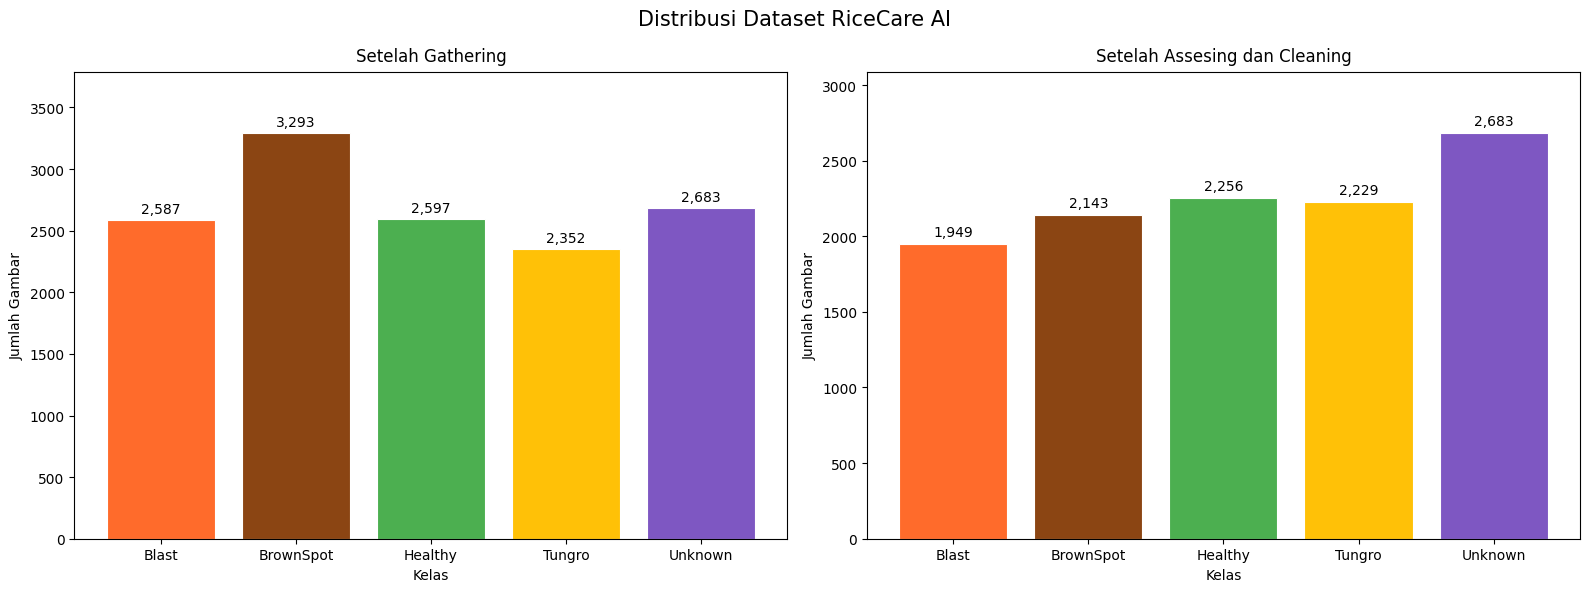

In [ ]:
# warna unik tiap kelas untuk konsistensi visualisasi
class_color = {
    "Blast":      "#FF6B2B",
    "BrownSpot":  "#8B4513",
    "Healthy":    "#4CAF50",
    "Tungro":     "#FFC107",
    "Unknown":    "#7E57C2",
}

# menghitung jumlah gambar per kelas dalam sebuah folder
def calculate_class(folder_utama):
    result = {}
    for class_name in sorted(os.listdir(folder_utama)):
        folder = os.path.join(folder_utama, class_name)
        if not os.path.isdir(folder):
            continue
        result[class_name] = len([
            f for f in os.listdir(folder)
            if os.path.isfile(os.path.join(folder, f))
        ])
    return result

# hitung distribusi kelas sebelum dan sesudah assesing dan cleaning
data_gathering = calculate_class(data_images)
data_cleaning = calculate_class(data_images_clean)

# membuat grafik perbandingan distribusi kelas sebelum dan sesudah assessing
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Distribusi Dataset RiceCare AI", fontsize=15)

for idx, (title_plot, data) in enumerate([
    ("Setelah Gathering", data_gathering),
    ("Setelah Assesing dan Cleaning", data_cleaning)
]):
    labels = list(data.keys())
    counts = list(data.values())
    colors = [class_color.get(l, "#9E9E9E") for l in labels]

    bars = axes[idx].bar(labels, counts, color=colors, width=0.8, edgecolor="white", linewidth=0.8)
    axes[idx].set_title(title_plot, fontsize=12, pad=8)
    axes[idx].set_xlabel("Kelas", fontsize=10)
    axes[idx].set_ylabel("Jumlah Gambar", fontsize=10)
    axes[idx].set_ylim(0, max(counts) * 1.15)

    # menampilkan angka jumlah gambar di atas tiap bar
    for bar, count in zip(bars, counts):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f"{count:,}",
            ha="center", va="bottom",
            fontsize=10
        )

# menampilkan ringkasan jumlah gambar per kelas setelah gathering
print("\nSetelah gathering")
print(f"\n{split.upper()}")
total = 0
for class_name in sorted(os.listdir(data_images)):
    folder = os.path.join(data_images, class_name)
    if not os.path.isdir(folder): continue
    count = len(os.listdir(folder))
    total += count
    print(f"   {class_name}: {count:,}")
print(f"Total: {total:,}")

# menampilkan ringkasan jumlah gambar per kelas setelah assessing
print("\nSetelah Assesing dan Cleaning")
print(f"\n{split.upper()}")
total = 0
for class_name in sorted(os.listdir(data_images_clean)):
    folder = os.path.join(data_images_clean, class_name)
    if not os.path.isdir(folder): continue
    count = len(os.listdir(folder))
    total += count
    print(f"   {class_name}: {count:,}")
print(f"Total: {total:,}")

plt.tight_layout()
plt.savefig("distribusi_dataset.png", dpi=300, bbox_inches="tight")
plt.show()


**Insight:** Total dataset setelah gathering dari berbagai sumber di kaggle adalah 13.512 gambar. Lalu dilakukan assesing dan cleaning data dengan cara memeriksa data korup, menghapus duplikasi data, mengkonversi ukuran gambar, mode warna dan format untuk menyesuaikan dengan keperluan model MobileNetV2. Setelah melakukan cleaning, jumlah data menjadi 11.260 gambar.


Train & Test (sebelum augmentasi)

TRAIN
   Blast: 1,559
   BrownSpot: 1,714
   Healthy: 1,804
   Tungro: 1,783
   Unknown: 2,000
Total: 8,860

TEST
   Blast: 390
   BrownSpot: 429
   Healthy: 452
   Tungro: 446
   Unknown: 537
Total: 2,254


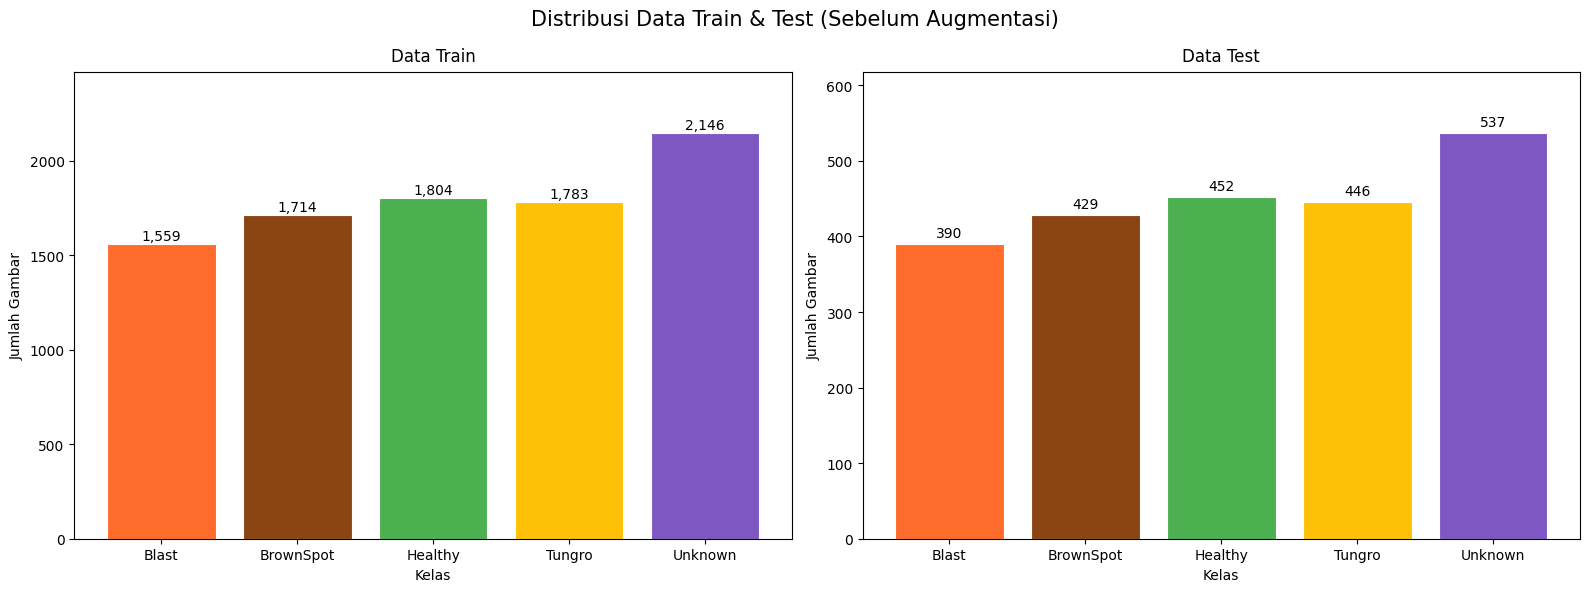

In [ ]:
# distribusi dataset untuk train dan test (setelah augmentasi)

data_dir = "data/split"
# Menghitung jumlah gambar per kelas dalam satu split (train/test)
def calculate_split(data_dir, split):
    hasil = {}
    split_path = os.path.join(data_dir, split)
    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path):
            continue
        hasil[class_name] = len([
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
        ])
    return hasil
# Data train sebelum augmentasi
data_train_before = {
    "Blast":      1559,
    "BrownSpot": 1714,
    "Healthy":    1804,
    "Tungro":     1783,
    "Unknown":    2146,
}
data_test         = calculate_split(data_dir, "test")

# Membuat grafik perbandingan distribusi data train dan test sebelum augmentasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Distribusi Data Train & Test (Sebelum Augmentasi)", fontsize=15)

for idx, (judul, data) in enumerate([
    ("Data Train", data_train_before),
    ("Data Test",  data_test)
]):
    labels = list(data.keys())
    counts = list(data.values())
    colors = [class_color.get(l, "#9E9E9E") for l in labels]

    bars = axes[idx].bar(labels, counts, color=colors, width=0.8, edgecolor="white", linewidth=0.8)
    axes[idx].set_title(judul, fontsize=12, pad=8)
    axes[idx].set_xlabel("Kelas", fontsize=10)
    axes[idx].set_ylabel("Jumlah Gambar", fontsize=10)
    axes[idx].set_ylim(0, max(counts) * 1.15)

    # Menampilkan angka jumlah gambar di atas tiap bar
    for bar, count in zip(bars, counts):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{count:,}",
            ha="center", va="bottom",
            fontsize=10
        )

# Mencetak ringkasan jumlah gambar asli (tanpa augmentasi) per kelas
print("\nTrain & Test (sebelum augmentasi)")
for split in ["train", "test"]:
    print(f"\n{split.upper()}")
    total = 0
    for class_name in sorted(os.listdir(os.path.join(data_dir, split))):
        folder = os.path.join(data_dir, split, class_name)
        if not os.path.isdir(folder): continue
        # hitung file asli saja, skip file hasil augmentasi
        count = len([f for f in os.listdir(folder) if not f.startswith("aug_")])
        total += count
        print(f"   {class_name}: {count:,}")
    print(f"Total: {total:,}")

plt.tight_layout()
plt.savefig("train_test.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** Membagi dataset menjadi 80% data train dan 20% data test. Data train digunakan untuk melatih model untuk mengenali pola penyakit sebanyak 8.860 gambar, sedangkan data test digunakan untuk mengevaluasi model pada data yang belum dilihat sebelumnya sebanyak 2.254 gambar.

## 2. Bagaimana perbandingan distribusi data train sebelum dan sesudah proses augmentasi

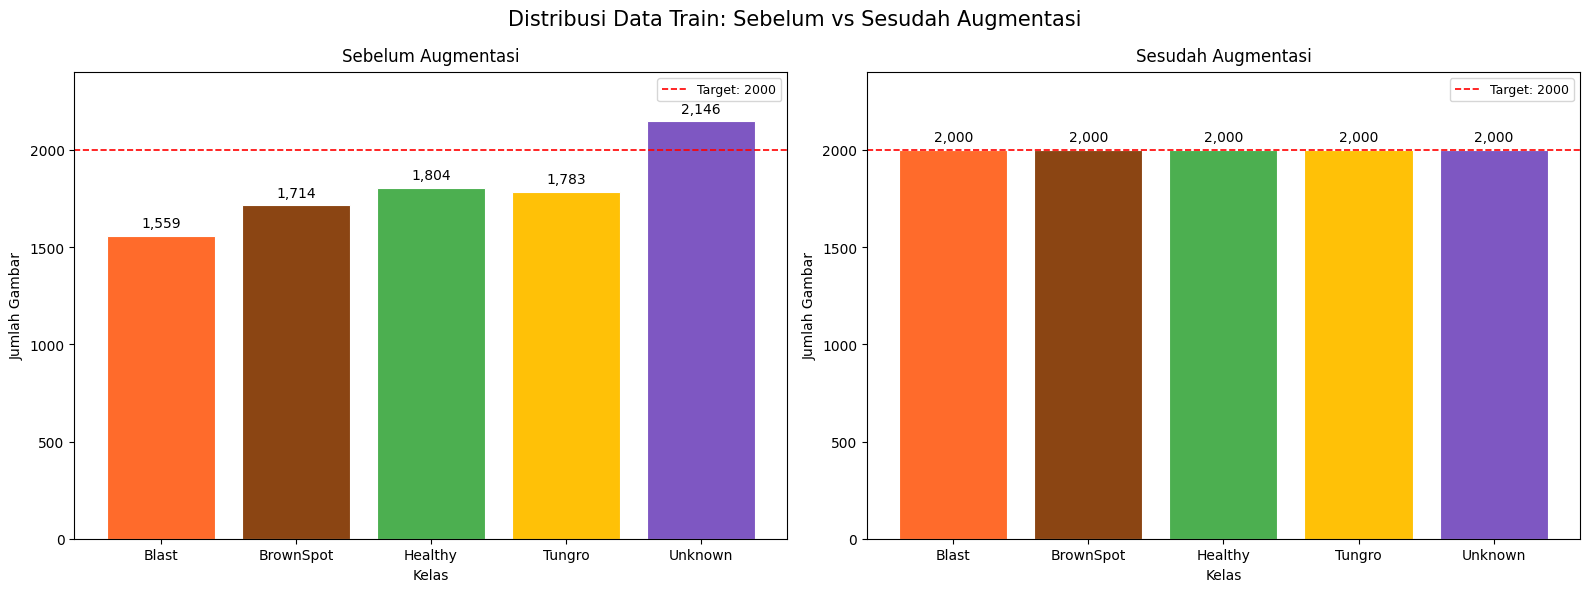

In [ ]:
# Membandingkan distribusi data train sebelum dan sesudah augmentasi
data_train_after = calculate_split(data_dir, "train")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Distribusi Data Train: Sebelum vs Sesudah Augmentasi", fontsize=15)

for idx, (judul, data) in enumerate([
    ("Sebelum Augmentasi", data_train_before),
    ("Sesudah Augmentasi", data_train_after)
]):
    labels = list(data.keys())
    counts = list(data.values())
    colors = [class_color.get(l, "#9E9E9E") for l in labels]

    bars = axes[idx].bar(labels, counts, color=colors, width=0.8, edgecolor="white", linewidth=0.8)
    axes[idx].set_title(judul, fontsize=12, pad=8)
    axes[idx].set_xlabel("Kelas", fontsize=10)
    axes[idx].set_ylabel("Jumlah Gambar", fontsize=10)
    axes[idx].set_ylim(0, 2400)

    # Menampilkan garis merah putus-putus sebagai penanda target 2000 gambar
    axes[idx].axhline(y=2000, color="red", linestyle="--", linewidth=1.2, label="Target: 2000")
    axes[idx].legend(fontsize=9)

    # Menampilkan angka jumlah gambar di atas tiap bar
    for bar, count in zip(bars, counts):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f"{count:,}",
            ha="center", va="bottom",
            fontsize=10
        )

plt.tight_layout()
plt.savefig("train_augmentasi.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** Data yang sudah dibagi mengalami ketidakseimbangan data, sehingga perlu melakukan teknik balancing menggunakan augmentasi dan mengurangi jumlah sampel yang melebihi target (2000 gambar per kelas). Teknik Augmentasi dan pengurangan data dipakai hanya untuk data train. Mengapa data test tidak? karena data test harus tetap merepresentasikan kondisi nyata dari dataset yang dikumpulkan.


Kelas terbanyak berada pada unknown, yaitu 2.146 gambar dan kelas dengan jumlah gambar paling sedikit adalah blast, yaitu 1559 gambar. Teknik yang digunakan antara lain, rotasi, flip horizontal dan vertikal, brightness & contrast adjustment, dan blur untuk data baru pada tiap kelas. Untuk dataset yang berlebih, seperti data unknown, digunakan pemilihan data secara acak untuk dihapus dan disesuikan dengan jumlah target 2000 gambar.


## 3. Bagaimana karakteristik visual gambar daun padi pada masing-masing kelas penyakit?

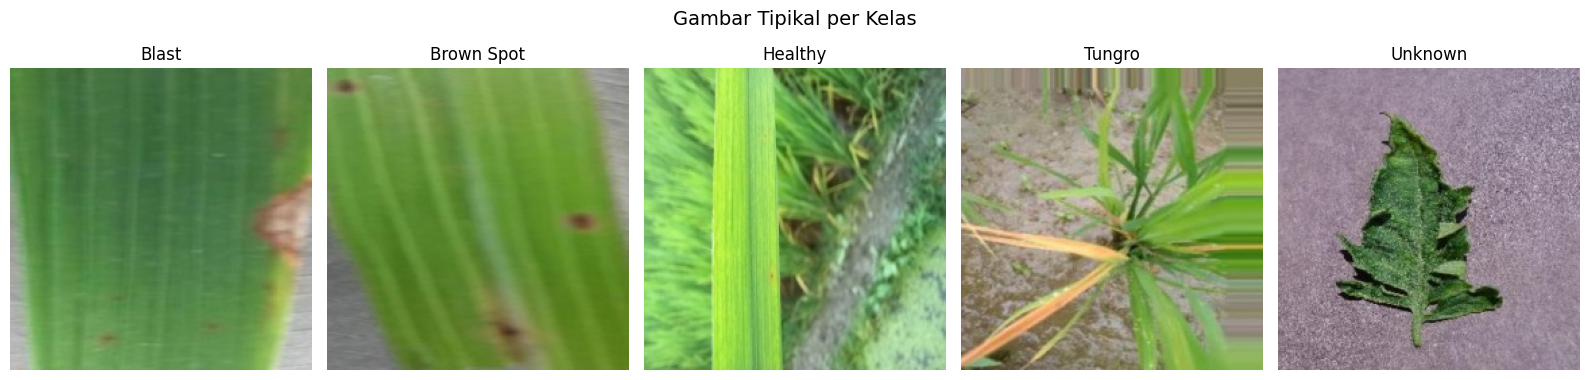

In [ ]:
# gambar tipikal

# gambar asli yang paling mendekati rata-rata kelasnya
# Mapping nama folder ke label tampilan yang lebih rapi
class_folder = ["Blast", "BrownSpot", "Healthy", "Tungro", "Unknown"]
class_label  = ["Blast", "Brown Spot", "Healthy", "Tungro", "Unknown"]
folder_to_label = dict(zip(class_folder, class_label))

# Mencari satu gambar paling representatif per kelas
tipical_image = {}
for folder, label in folder_to_label.items():
    folder_path  = os.path.join(data_images_clean, folder)
    all_images = [
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if f.lower().endswith(".jpg")
    ][:50]

    if all_images:
        arrays   = [np.array(Image.open(p).resize((224, 224)).convert("RGB")) for p in all_images]
        mean_arr = np.mean(arrays, axis=0)  # rata-rata piksel semua gambar
        jarak    = [np.linalg.norm(arr - mean_arr) for arr in arrays] # jarak tiap gambar ke rata-rata
        tipical_image[label] = arrays[np.argmin(jarak)] # pilih gambar dengan jarak terkecil
    else:
        # fallback jika folder kosong: gunakan gambar noise acak
        tipical_image[label] = np.random.randint(80, 180, (224, 224, 3), dtype=np.uint8)

# Menampilkan gambar tipikal tiap kelas secara berdampingan
fig, axes = plt.subplots(1, len(class_label), figsize=(16, 4))
fig.suptitle("Gambar Tipikal per Kelas", fontsize=14)
plt.subplots_adjust(top=0.85)


for idx, label in enumerate(class_label):
    axes[idx].imshow(tipical_image[label])
    axes[idx].set_title(label, color="black", fontsize=12)
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("karakteristik_visual.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** Gambar asli yang paling merepresentasikan karakteristik tiap kelas (dipilih berdasarkan kedekatan ke rata-rata kelas). Jika dilihat, karakteristik dari tiap kelas memiliki ciri khasnya masing-masing:
- Blast: Terdapat bercak coklat di tengah daun.
- Brown Spot: Terdapat bercak bulan kecil berwarna coklat yang tersebar di permukaan daun.
- Tungro: Terdapat warna yang menguning pada daun dan cukup merata.
- Healthy: Tidak ada perubahan warna atau bercak (hijau segar).
- Unknown: Gambar acak yang digunakan sebagai perbandingan dengan data kelas penyakit daun padi.


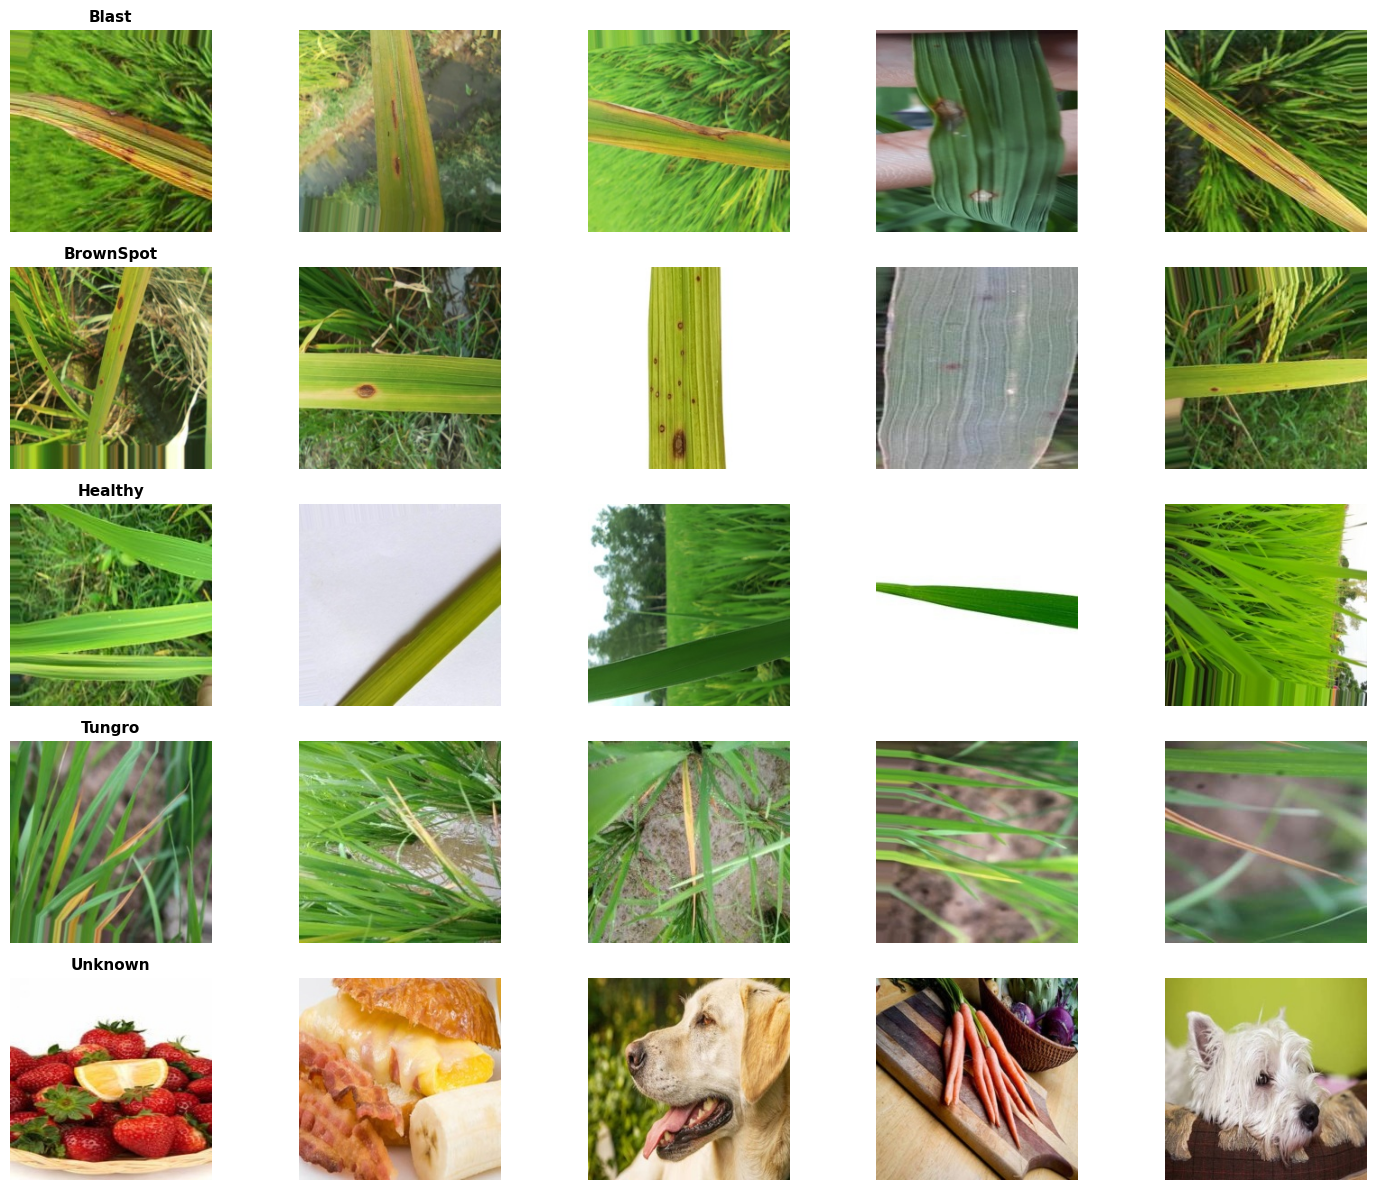

In [ ]:
# visualisasi sampel gambar per kelas
# Menampilkan 5 sampel gambar acak per kelas dari data train
train_dir = "data/split/train"
classes   = sorted(os.listdir(train_dir))
n_samples = 5

fig, axes = plt.subplots(len(classes), n_samples, figsize=(15, 12))

for row, label in enumerate(classes):
    class_path = os.path.join(train_dir, label)
    samples    = random.sample(os.listdir(class_path), n_samples)
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(class_path, fname)).resize((224, 224))
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        # tampilkan nama kelas hanya di kolom pertama tiap baris
        if col == 0:
            axes[row, col].set_title(label, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("sampel_gambar.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Bagaimana distribusi rata-rata nilai RGB pada setiap kelas penyakit?

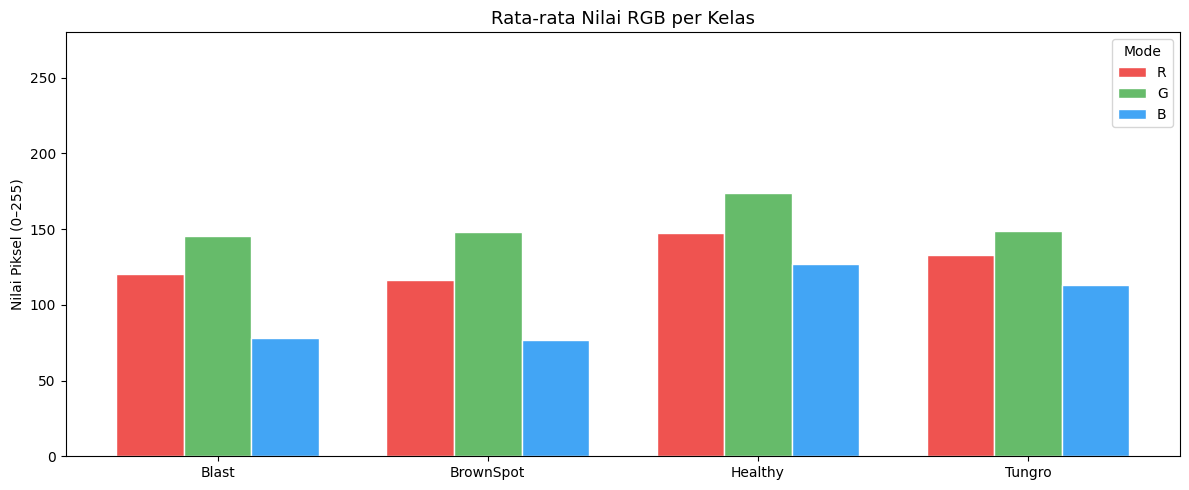

In [ ]:
# Hitung rata-rata RGB per kelas

rgb_class = {}
for class_name in sorted(os.listdir(data_images_clean)):
    folder = os.path.join(data_images_clean, class_name)
    if not os.path.isdir(folder):
        continue
    # skip kelas Unknown karena tidak memiliki ciri visual spesifik
    if class_name == "Unknown":
        continue
    images = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(".jpg")][:200]
    arrays = [np.array(Image.open(p).convert("RGB")) for p in images]
    rgb_class[class_name] = {
        "R": np.mean([a[:,:,0].mean() for a in arrays]),
        "G": np.mean([a[:,:,1].mean() for a in arrays]),
        "B": np.mean([a[:,:,2].mean() for a in arrays]),
    }

# Menampilkan grafik batang perbandingan rata-rata RGB antar kelas
plot_class = list(rgb_class.keys())
x     = np.arange(len(plot_class))
w     = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, [rgb_class[k]["R"] for k in plot_class], w, label="R", color="#ef5350", edgecolor="white")
ax.bar(x,     [rgb_class[k]["G"] for k in plot_class], w, label="G", color="#66bb6a", edgecolor="white")
ax.bar(x + w, [rgb_class[k]["B"] for k in plot_class], w, label="B", color="#42a5f5", edgecolor="white")

ax.set_title("Rata-rata Nilai RGB per Kelas", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(plot_class)
ax.set_ylabel("Nilai Piksel (0–255)")
ax.set_ylim(0, 280)
ax.legend(title="Mode")

plt.tight_layout()
plt.savefig("sebaran_RGB.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** Nilai G (Green) yang tinggi pada kelas Healthy mengindikasikan daun yang lebih hijau dan segar dibanding kelas penyakit.

## 📁 Data Dictionary & Kualitas Dataset

Berikut adalah **Data Dictionary** beserta ringkasan kualitas dari dataset gambar daun padi untuk **RiceCare AI** setelah tahap *cleaning*, augmentasi, penyeragaman ukuran, dan format *file*.

---

#### 1. Tabel Data Dictionary

Tabel ini merupakan speisifikasi atribut dalam DataFrame (df_summary) yang sudah dibersihkan serta memenuhi standar dan siap dipakai untuk pemrosesan *Deep Learning*.

| Nama Atribut | Tipe Data | Deskripsi | Spesifikasi |
| :--- | :--- | :--- | :--- |
| **label** | object | Kelas daun padi yang menjadi target prediksi model | Blast, BrownSpot, Healthy, Tungro |
| **filename** | object | Nama gambar yang tersimpan dalam penyimpanan | Contoh: BrownSpot_1222.jpg |
| **width** | integer | Lebar dimensi gambar dalam satuan piksel | 224 |
| **height** | integer | Tinggi dimensi gambar dalam satuan piksel | 224 |
| **mode warna** | object | Warna piksel gambar yang digunakan | RGB |
| **format** | object | Format gambar | JPEG |

---

#### 2. Ringkasan Kualitas Dataset

* **Keseimbangan Kelas:** Data sudah seimbang dengan jumlah **2.000 gambar per kelas**, sehingga total keseluruhan data *train* adalah **10.000 gambar**.
* **Ukuran Piksel:** Seluruh gambar memiliki ukuran yang sama, yaitu **224 × 224 piksel**. Ukuran ini disesuaikan agar sesuai dengan arsitektur *Transfer Learning* **MobileNetV2**.
* **Format & Warna:** Seluruh gambar menggunakan mode warna **RGB** dan disimpan dalam format **JPEG (.jpg)** untuk mengoptimalkan memori.

---